In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('/content/Iris.csv')
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

In [3]:
# 2. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# 3. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [5]:
# 4. Experiment with different values of K
k_values = [1, 3, 5, 7, 9]

for k in k_values:
    print(f"\nK = {k}")
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")


K = 1
Accuracy: 0.98

K = 3
Accuracy: 1.00

K = 5
Accuracy: 1.00

K = 7
Accuracy: 1.00

K = 9
Accuracy: 1.00


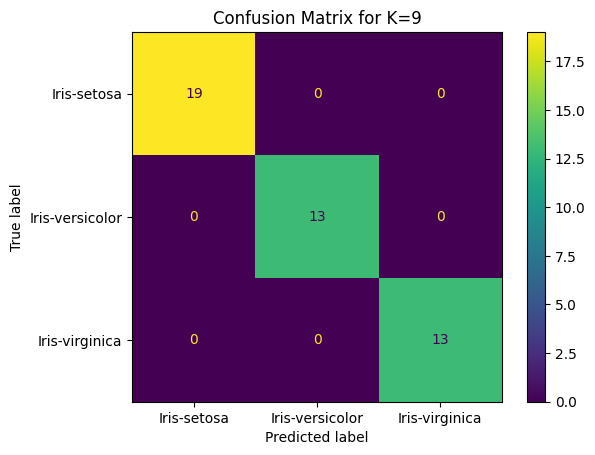

In [9]:
# Confusion matrix - Indented to be inside the loop
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title(f'Confusion Matrix for K={k}')
plt.show()

In [10]:
# 5. Visualize decision boundaries using 2D PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_2d, y_train_2d)

KNeighborsClassifier()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

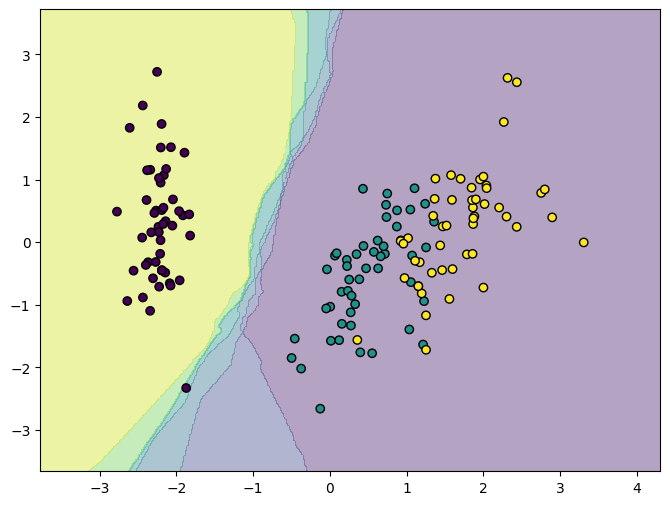

In [13]:
# Plot decision boundary
h = .02
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Get predicted probabilities instead of class labels
Z_probs = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])

# Choose one class probability for contour plotting (e.g., probability of 'Iris-setosa')
Z = Z_probs[:, 0].reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4)  # Now using numeric probability values for Z
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=pd.Categorical(y).codes, edgecolor='k', cmap='viridis')
plt.legend(handles=scatter.legend_elements()[0], labels=df['Species'].unique())
plt.title("Decision Boundary (K=5) using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()